In [2]:
import urllib.request
import zipfile
import os
import ssl 

try:
    os.mkdir("files")
except:
    pass

ssl._create_default_https_context = ssl._create_unverified_context

with urllib.request.urlopen('https://courses.cs.tau.ac.il/pyProg/2425a/resources/notebook_resources.zip') as f:
    content = f.read()

with open('files/notebook_resources.zip', 'wb') as f:
    f.write(content)

with zipfile.ZipFile('files/notebook_resources.zip', 'r') as zip_ref:
    zip_ref.extractall('files')

print(os.listdir('files'))

import imageio
import numpy as np
import matplotlib.pyplot as plt

['baby.png', 'countries-of-the-world.csv', 'dialation.png', 'dialation_2.png', 'dog.png', 'dog_noised.png', 'erosion.png', 'erosion_2.png', 'evil_morty_1.png', 'evil_morty_change.png', 'evil_morty_change_3.png', 'evil_morty_change_noised.png', 'evil_morty_segmentation.png', 'ex1.csv', 'ex2.csv', 'foods.txt', 'infile1.txt', 'infile2.txt', 'koala.png', 'monday.txt', 'notebook_resources.zip', 'orders_2_2024.csv', 'orders_3_2024.csv', 'orders_4_2024.csv', 'out.txt', 'products2.csv', 'ship.png', 'StudentsGrades.csv', 'sunday.txt', 'witcher_1.csv', 'witcher_2.csv', 'woman_noised.png', '__MACOSX']


# פעולות בסיסיות על מערכי NumPy

ביחידה זו נכיר תכונות ופעולות שונות שניתן לבצע במערכי NumPy, ונדגים אותם על המערכים "רגילים" כמו גם על מערכים המייצגים תמונות.

## שליפת מימדי המטריצה

נתבונן במטריצה הבאה:

In [45]:
b = np.array([[3, 4, 5], [6, 7, 8]])
print('b is \n' , b)

b is 
 [[3 4 5]
 [6 7 8]]


למדנו ביחידות הקודמות ש`len` תחזיר לנו את **אורך** האובייקט. מה לדעתם הערך שיוחזר מ`len` עבור המטריצה שלנו? 

In [50]:
print(len(b))

2



כלומר, עבור מערכי NumPy, הפונקציה `len` מחזירה את **מספר השורות** במטריצה.  
במערך חד-מימדי `len` תחזיר את מספר האלמנטים במערך (בדומה לרשימה).

ואם נרצה לקבל את כל מימדי המטריצה שלנו? לצורך כך נשתמש בשדה `shape`:

In [49]:
print(b.shape)

(2, 3)


```{admonition} **שימו לב**
:class: error
`shape` הוא שדה, ואינו מתודה. הוא אינו פונקציה בכלל, ולכן אין שימוש בסוגריים בקריאה.


```

## שחלוף (transpose) ושינוי מימדים

ניתן גם **לשחלף** את המטריצה שלנו ע"י שימוש בשדה `T` (כמו Transpose).   
שימו לך שמימדי המטריצה המשוחלפת התהפכו!

In [48]:
print('b is \n',b)
print('b transposed is \n',b.T)
print('b transposed dimensions are: ',b.T.shape)

b is 
 [[3 4 5]
 [6 7 8]]
b transposed is 
 [[3 6]
 [4 7]
 [5 8]]
b transposed dimensions are:  (3, 2)


מלבד שחלוף, קיימת פונקציה בשם `reshape`, המאפשרת לשנות את מבנה המטריצה. מתודה זה תשים את האיברים של המטריצה המקורית, **לפי סדר השורות**, במטריצה חדשה בעלת מימדים שהועברו בקלט.


In [47]:
c = b.reshape((3,2))
print(c)

[[3 4]
 [5 6]
 [7 8]]


```{admonition} **שימו לב**
:class: error
המימדים המועברים בקלט המתודה `reshape` חייבים לייצג מטריצה אשר תכיל את **כל איברי המערך** ממנו הופעלה המתודה. אחרת נקבל שגיאה.

בנוסף, בדוגמאות לעיל, פלט המתודה `reshape` אינו זהה למטריצה המשוחלפת. במטריצה המשוחלפת השורות הופכות לעמודות, וב-`reshape` סדר האיברים לפי שורות נשמר. 
```



כעת נדגים כיצד הפעולות שראינו למעלה מתבטאות במטריצות המייצגות תמונות:

על מנת לקבל את מספר השורות והעמודות בתמונה נוכל להשתמש בשדה `shape`:

In [3]:
im_dog = imageio.v3.imread('files/dog.png')
print(im_dog.shape)

(302, 335)


ועל מנת להפוך את התמונה על צידה נוכל להשתמש בתכונה `T`

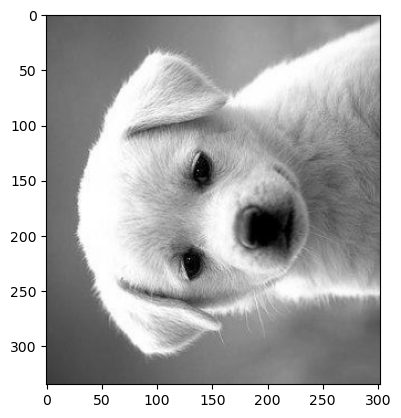

In [53]:
im_transposed = im_dog.T
plt.imshow(im_transposed,cmap='gray')

## גישה לערכים במטריצה

#### חילוץ ערך בודד

בדומה לרשימות, גם ב-NumPy ניתן לגשת לערכים ספציפיים בתמונה, כולל Slicing. 

```{admonition} **תזכורת**
:class: note

עד כה, ברשימות דו-מימדיות, ניגשנו לאינדקס השורות `x` ואינדקס העמודות `y` בצורה `mat[x][y]`.
```


במערכי NumPy, ניתן לגשת לאיבר (או איברים) במטריצה ע"י אינדקס השורות (`x`) והעמודות (`y`) יחדיו **בתוך הסוגריים המרובעים**. כלומר, בצורה: `mat[x,y]`. 

נדגים זאת בקוד הבא:

תחילה ניצור מטריצה 3X3 של סדרת המספרים בין 0 ל8:

In [4]:
a=np.arange(9).reshape((3,3))
print(a)

[[0 1 2]
 [3 4 5]
 [6 7 8]]


כעת נחלץ את האיבר האמצעי של המטריצה:

In [66]:
print(a[1, 1])

4


כלומר, חילצנו את האיבר שנמצא באינדקס 1 של השורות (שורה שניה) ובאינדקס 1 של עמודות (עמודה שניה).

ביצוע slicing בצורה זו מאפשר גם בחירה של יותר מעמודה או שורה אחת. לדוגמא, נחלץ את שתי השורות התחתונות בעמודה הימנית ביותר:

In [8]:
print(a[1: ,2])

[5 8]


**נסו בעצמכם!** השתמשו בslicing כדי לקבל את המטריצה:
``` 
[[1 2]
[4 5]]
```

In [11]:
# Write your code here


ניתן אף לפרט בדיוק אילו אינדקסים רוצים להחזיר ובאיזה סדר באמצעות רשימה (או Iterable מספרי אחר) בשורות או בעמודות. לדוגמא:

In [79]:
print(a[[2,1,2], 2])

[8 5 8]


הפעם, הדפסנו מעמודה 2 את שורה 2, שורה 1 ושורה 2 (שוב!).

#### חילוץ עמודה/שורה שלמה

כדי להחזיר שורה שלמה, פשוט לא נעביר אינדקס עמודות. לדוגמא, כך נחזיר את כל השורה השניה:

In [67]:
print(a[1])

[3 4 5]


וכדי להחזיר **עמודה** שלמה - לא נוכל להשתמש באותה דרך, הרי נצטרך לשים משהו לפני הפסיק. 
במקרה זה, נשים נקודותיים `:`. בדומה לslicing, נקודותיים מחזירה את כל הטווח (כלומר, את כל השורות).

לדוגמא, כך נחזיר את העמודה השניה:

In [68]:
print(a[:,1])

[1 4 7]


#### תרגול: החזרת תתי-מטריצות באמצעות Slicing

תחילה נגדיר את המטריצה `mat` הבאה:

In [ ]:
mat= np.array([[0, 1, 2,3,4,5],
            [10, 11, 12,13,14,15],
            [20, 21, 22,23,24,25],
            [30, 31, 32,33,34,35],
            [40, 41, 42,43,44,45],
            [50, 51, 52,53,54,55]])
print(mat)

כעת, עבור כל אחד מארבעת הצבעים במטריצה להלן, כתבו **שורה בודדת** המבצעת Slicing על `mat` כדי לקבל את תת-מטריצה המסומנת באותו הצבע:  


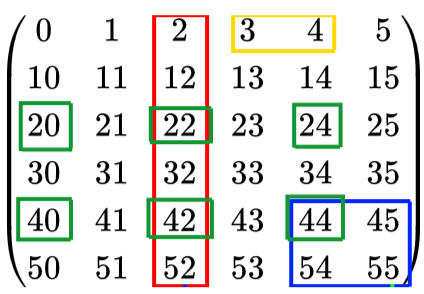

In [12]:
%%html
<img src="..." />

**<span style='color:orange'> חיתוך שורות </span>**

In [ ]:
# Write you code here

```{admonition} **פתרון**
:class: dropdown, tip
    print(mat[0,3:5])
```

**<span style='color:red'> חיתוך עמודות </span>**

In [ ]:
# Write you code here

```{admonition} **פתרון**
:class: dropdown, tip
    print(mat[:,2])
```

**<span style='color:blue'>תת מטריצה רציפה </span>**

In [ ]:
# Write you code here

```{admonition} **פתרון**
:class: dropdown, tip
    print(mat[4:,4:])
```


**<span style='color:green'> תת-מטריצה עם קפיצות </span>**

In [ ]:
# Write you code here

```{admonition} **פתרון**
:class: dropdown, tip
    print(mat[2::2,::2])
```

## עריכת ערכים במטריצה

באופן אנלוגי לרשימות, גם כאן ניתן לבצע **השמות של איברים** למטריצה קיימת באמצעות פירוט האינדקסים הרלוונטיים:

In [69]:
a[1, 1] = 10
print(a)

[[ 0  1  2]
 [ 3 10  5]
 [ 6  7  8]]


ניתן גם להחזיר או לבצע השמה על תת-קבוצה של שורות/עמודות. לדוגמא:

In [73]:
a[0,0:2] = a[2,1:3]*10
print(a)

[[70 80  2]
 [ 3 10  5]
 [ 6  7  8]]


## עיבוד תמונה באמצעות slicing

מאחר שתמונות הן מטריצות מספרים בטווח 0-256, ניתן **לערוך תמונות באמצעות שינוי ערכי המטריצה**.

In [8]:
new_fig = np.zeros((100,100))
new_fig[::2,::2] = 255

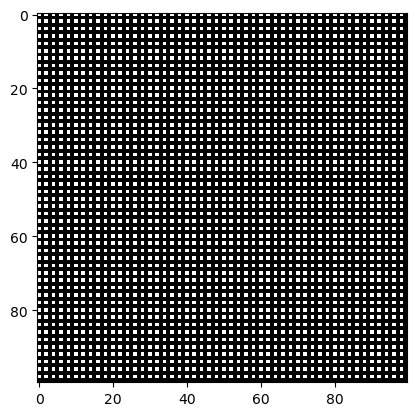

In [9]:
plt.imshow(new_fig, cmap=plt.cm.gray)

#### דוגמא: הורדת איכות של תמונה

נניח שאנחנו רוצים להציג תמונה, אבל נרצה לשמור פחות פיקסלים בזכרון.
לדוגמא, נעשה זאת על ידי בחירה שרירותית - ניקח כל פיקסל עשירי מהתמונה.

In [4]:
im2=im_dog[::10,::10]

In [9]:
import json
from jupyterquiz import display_quiz

example = '''
[
  {
    "question": "אם הייתה לנו תמונה ריבועית בגודל 10 על 10 פיקסלים, כמה פיקסלים יהיו בה במקור?",
    "type": "numeric",
    "answers": [
      {
        "type": "value",
        "value": 100,
        "correct": true,
        "feedback": "נכון!"
      },
      {
        "type": "default",
        "feedback": "לא נכון"
      }
    ]
  },
      {
    "question": "אם הייתה לנו תמונה ריבועית בגודל 10 על 10 פיקסלים, כמה פיקסלים יהיו בה לאחר השינוי?",
    "type": "numeric",
    "answers": [
      {
        "type": "value",
        "value": 1,
        "correct": true,
        "feedback": "נכון!"
      },
      {
        "type": "default",
        "feedback": "לא נכון"
      }
      ]
      }
]
'''
myquiz = json.loads(example)
display_quiz(myquiz)


<IPython.core.display.Javascript object>

וכעת, אם נציג את התמונה באותו גודל כמו המקורית - נקבל תמונה מפוקסלת.
אמנם הפרטים כבר לא ברורים, אבל עדיין ניתן לזהות את התמונה!

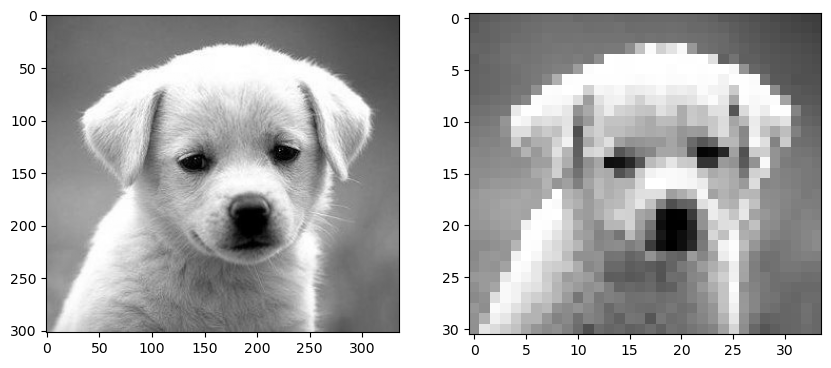

In [5]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(im_dog, cmap=plt.cm.gray)
plt.subplot(1, 2, 2)
plt.imshow(im2, cmap=plt.cm.gray)

## ערכים בוליאניים והשוואות במערכי NumPy

השוואות במערכי NumPy מתבצעות בדומה לאופרטורים מתמטיים.  
אם משווים בין שני מערכים מאותם מימדים, הההשוואה נעשית איבר איבר.   
אם משווים בין מערך לערך מסוים, כלל האיברים יושוו לערך.  
בשני המקרים, נקבל **מערך בוליאני במימדי המערך המקורי** המכיל את תוצאות ההשוואה עבור כל איבר.


דוגמאות:

In [10]:
a = np.arange(5)
b = np.arange(4,-1,-1)

print("a: ", a)
print("b: ", b)

print(a<2)
print(a==b)

a:  [0 1 2 3 4]
b:  [4 3 2 1 0]
[ True  True False False False]
[False False  True False False]


In [15]:
a = np.array([[1,2,3],[4,5,6]])
b = np.array([[1,2,4],[2,4,6]])

print("a:\n", a)
print("b:\n", b)

print(b<3)
print(a==b)

a:
 [[1 2 3]
 [4 5 6]]
b:
 [[1 2 4]
 [2 4 6]]
[[ True  True False]
 [ True False False]]
[[ True  True False]
 [False False  True]]


### פעולות סיכומיות על מערכים בוליאניים
בהינתן מערך המכיל ערכים בוליאניים, ניתן להשתמש ב`any` על מנת לבדוק אם **לפחות אחד** מהערכים במערך הוא `True`, כמו **פעולת `or`** בין כל איברי המערך.   
באופן אנלוגי, ניתן גם להשתמש ב`all` על מנת לבדוק אם **כל** הערכים במערך הם `True`, כמו **פעולת `and`** בין כל איברי המערך. 

In [24]:
a = np.arange(5)
b = np.arange(4,-1,-1)

print("a: ", a)
print("b: ", b)


comp1=a==b                   # comp1 is a boolean array
print("### a==b ###")
print("any: ", comp1.any())
print("all: ",comp1.all())

print("### a<6 ###")
comp2=a<6                   # comp2 is a boolean array
print("any: ",comp2.any())
print("all: ",comp2.all())

print("### a>6 ###")
comp3=a>6                   # comp3 is a boolean array
print("any: ",comp3.any())
print("all: ",comp3.all())

a:  [0 1 2 3 4]
b:  [4 3 2 1 0]
### a==b ###
any:  True
all:  False
### a<6 ###
any:  True
all:  True
### a>6 ###
any:  False
all:  False


כפי שלמדנו ניתן להתייחס לערכים הבוליאניים `False` ו-`True` גם כ-0 ו-1 בהתאמה. 

לכן, ניתן להפעיל עליהם גם **מתודות ארימתטיות** על מערכים.
לדוגמא: המתודה `nonzero` מחזירה את כל האינדקסים במערך בהם מופיע ערך שאינו 0. כלומר, במקרה של מטריצה בוליאנית, כל מקום בו מופיע `True`.

In [25]:
print("### a==b ###")
print(comp1.nonzero())

### a==b ###
(array([2]),)


דוגמא נוספת היא המתודה `sum` הסוכמת את כל איברי המטריצה.

In [26]:
print("### a==b ###")
print(comp1.sum())

### a==b ###
1


## נסו בעצמכם!

ממשו את הפונקציה `array_any` אשר מקבלת מערך בוליאני דו-מימדי, ומחזירה אם קיים בו איבר שהוא `True`. **אין להשתמש במתודה `any`!**

In [ ]:
def array_any(array):
    # Write your code here
    pass

```{admonition} **לחצו כאן כדי לצפות בפתרון**
:class: dropdown, tip

``` python
def array_any(array):
    # Write your code here
    return array.sum()>=1
```

כעת ממשו את הפונקציה `array_all` אשר מקבלת מערך בוליאני דו-מימדי, ומחזירה אם כל האיברים בו הם `True`. **אין להשתמש במתודה `all`!**

In [ ]:
def array_all(array):
    # Write your code here
    pass

```{admonition} **לחצו כאן כדי לצפות בפתרון**
:class: dropdown, tip

``` python
def array_all(array):
    # Write your code here
    return array.sum() == array.shape[0] * array.shape[1]
````